# Walmart Store Sales — Prophet v1: external covariates

This controlled Prophet experiment evaluates whether `features.csv` improves per-series forecasts beyond the seasonal/holiday baseline.

Main choices:

- validation is the last `39` weeks of `train.csv`, matching the Kaggle test horizon;
- metric is Kaggle-style WMAE, with holiday rows weighted by `5`;
- all Store-Dept series are evaluated (`top_n_series=None`);
- the baseline Prophet trend, yearly seasonality and holiday calendar are preserved;
- only known store-date covariates are added: Temperature, Fuel_Price, CPI, Unemployment and MarkDown1–5;
- each feature is imputed using only its store/date feature table, never sales targets.

Run all cells in order. This notebook is for validation experimentation; final refit and submission stay in the later inference notebook.

In [1]:
%pip install -q "prophet>=1.1,<2" "wandb>=0.19,<1" "pandas>=2.2,<3" "numpy>=1.26,<3" "matplotlib>=3.8,<4" "scikit-learn>=1.4,<2"


In [2]:
from __future__ import annotations

import json
import logging
import os
import platform
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wandb
from prophet import Prophet

warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)

pd.set_option("display.max_columns", 120)
print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "wandb": wandb.__version__,
})


{'python': '3.12.13', 'pandas': '2.2.2', 'numpy': '2.0.2', 'wandb': '0.28.0'}


In [3]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as exc:
    print(f"Not running in Colab or Drive unavailable: {exc}")


Mounted at /content/drive


## Configuration

Prophet fits one independent model for each `(Store, Dept)` series. `top_n_series=None` means every available series is included. The feature regressors are supplied by `features.csv` for both historical and Kaggle forecast dates, so they are known at prediction time.

In [4]:
SEED = 42
np.random.seed(SEED)

EXTERNAL_REGRESSORS = [
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",
]

CONFIG = {
    "seed": SEED,
    "validation_weeks": 39,
    "holiday_weight": 5.0,
    "top_n_series": None,
    "min_history_points": 52,
    "growth": "linear",
    "yearly_seasonality": True,
    "weekly_seasonality": False,
    "daily_seasonality": False,
    "seasonality_mode": "additive",
    "changepoint_prior_scale": 0.05,
    "seasonality_prior_scale": 10.0,
    "holidays_prior_scale": 10.0,
    "regressor_prior_scale": 5.0,
    "interval_width": 0.80,
    "prediction_clip_min": 0.0,
    "prediction_clip_max": 300000.0,
    "external_regressors": EXTERNAL_REGRESSORS,
    "wandb_project": "Walmart-Recruiting---Store-Sales-Forecasting",
    "wandb_entity": "kende23-n-a",
    "wandb_group": "prophet-experiments",
    "run_name": "prophet_v1_external_covariates_all_series_validation",
    "artifact_name": "prophet-v1-external-covariates-all-series-validation",
}

DATA_DIR = Path("/content/drive/MyDrive/walmart_competition_data")
OUTPUT_DIR = Path("/content/artifacts/prophet_v1_external_covariates")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG

{'seed': 42,
 'validation_weeks': 39,
 'holiday_weight': 5.0,
 'top_n_series': None,
 'min_history_points': 52,
 'growth': 'linear',
 'yearly_seasonality': True,
 'weekly_seasonality': False,
 'daily_seasonality': False,
 'seasonality_mode': 'additive',
 'changepoint_prior_scale': 0.05,
 'seasonality_prior_scale': 10.0,
 'holidays_prior_scale': 10.0,
 'regressor_prior_scale': 5.0,
 'interval_width': 0.8,
 'prediction_clip_min': 0.0,
 'prediction_clip_max': 300000.0,
 'external_regressors': ['Temperature',
  'Fuel_Price',
  'CPI',
  'Unemployment',
  'MarkDown1',
  'MarkDown2',
  'MarkDown3',
  'MarkDown4',
  'MarkDown5'],
 'wandb_project': 'Walmart-Recruiting---Store-Sales-Forecasting',
 'wandb_entity': 'kende23-n-a',
 'wandb_group': 'prophet-experiments',
 'run_name': 'prophet_v1_external_covariates_all_series_validation',
 'artifact_name': 'prophet-v1-external-covariates-all-series-validation'}

## Load data


In [5]:
required_files = ["train.csv", "test.csv", "features.csv", "stores.csv"]
missing_files = [name for name in required_files if not (DATA_DIR / name).exists()]
if missing_files:
    raise FileNotFoundError({"data_dir": str(DATA_DIR), "missing_files": missing_files})

train_raw = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["Date"])
test_raw = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["Date"])
features_raw = pd.read_csv(DATA_DIR / "features.csv", parse_dates=["Date"])
stores_raw = pd.read_csv(DATA_DIR / "stores.csv")

required_train = {"Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"}
required_test = {"Store", "Dept", "Date", "IsHoliday"}
missing = {
    "train": sorted(required_train.difference(train_raw.columns)),
    "test": sorted(required_test.difference(test_raw.columns)),
}
if any(missing.values()):
    raise ValueError(missing)

train_raw = train_raw.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)
test_raw = test_raw.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

profile = pd.DataFrame({
    "table": ["train", "test", "features", "stores"],
    "rows": [len(train_raw), len(test_raw), len(features_raw), len(stores_raw)],
    "columns": [train_raw.shape[1], test_raw.shape[1], features_raw.shape[1], stores_raw.shape[1]],
    "min_date": [train_raw.Date.min(), test_raw.Date.min(), features_raw.Date.min(), pd.NaT],
    "max_date": [train_raw.Date.max(), test_raw.Date.max(), features_raw.Date.max(), pd.NaT],
})
display(profile)
display(train_raw.head())


,table,rows,columns,min_date,max_date
0,train,421570,5,2010-02-05,2012-10-26
1,test,115064,4,2012-11-02,2013-07-26
2,features,8190,12,2010-02-05,2013-07-26
3,stores,45,3,NaT,NaT


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


## Split, series selection and covariate table

In [6]:
all_train_dates = pd.Index(sorted(train_raw["Date"].unique()), name="Date")
test_dates = pd.Index(sorted(test_raw["Date"].unique()), name="Date")
val_dates = all_train_dates[-CONFIG["validation_weeks"]:]
fit_dates = all_train_dates[:-CONFIG["validation_weeks"]]

if len(test_dates) != CONFIG["validation_weeks"]:
    raise ValueError(f"Expected test horizon {CONFIG['validation_weeks']}, got {len(test_dates)}")
if len(fit_dates) < CONFIG["min_history_points"]:
    raise ValueError("Not enough fit history for configured Prophet experiment.")

series_sales = (
    train_raw.groupby(["Store", "Dept"], as_index=False)["Weekly_Sales"]
    .sum()
    .sort_values("Weekly_Sales", ascending=False)
)
if CONFIG["top_n_series"] is None:
    top_series = series_sales[["Store", "Dept"]].copy()
else:
    top_series = series_sales.head(int(CONFIG["top_n_series"]))[["Store", "Dept"]].copy()

selected_keys = set(map(tuple, top_series[["Store", "Dept"]].to_numpy()))
selected_train = train_raw.merge(top_series.assign(_keep=1), on=["Store", "Dept"], how="inner").drop(columns="_keep")

missing_regressors = sorted(set(CONFIG["external_regressors"]).difference(features_raw.columns))
if missing_regressors:
    raise ValueError({"missing_feature_columns": missing_regressors})

# These are supplied by Kaggle for historical and test dates. Missing values are
# filled within each Store first, then from the date-wide median, then overall median.
store_feature_table = features_raw[["Store", "Date", *CONFIG["external_regressors"]]].copy()
store_feature_table = store_feature_table.drop_duplicates(["Store", "Date"]).sort_values(["Store", "Date"])
for column in CONFIG["external_regressors"]:
    store_feature_table[column] = pd.to_numeric(store_feature_table[column], errors="coerce")
    store_feature_table[column] = store_feature_table.groupby("Store")[column].transform(lambda s: s.ffill().bfill())
    date_median = store_feature_table.groupby("Date")[column].transform("median")
    store_feature_table[column] = store_feature_table[column].fillna(date_median)
    store_feature_table[column] = store_feature_table[column].fillna(store_feature_table[column].median()).fillna(0.0)

feature_coverage = (
    store_feature_table.groupby("Date", as_index=True)[CONFIG["external_regressors"]]
    .median()
    .reindex(pd.Index(sorted(set(all_train_dates).union(set(test_dates))), name="Date"))
)
if feature_coverage[CONFIG["external_regressors"]].isna().any().any():
    raise ValueError("Covariate table still has missing values after imputation.")

split_summary = {
    "validation_weeks": CONFIG["validation_weeks"],
    "fit_start": str(fit_dates.min().date()),
    "fit_end": str(fit_dates.max().date()),
    "validation_start": str(val_dates.min().date()),
    "validation_end": str(val_dates.max().date()),
    "test_start": str(test_dates.min().date()),
    "test_end": str(test_dates.max().date()),
    "all_train_rows": int(len(train_raw)),
    "selected_train_rows": int(len(selected_train)),
    "top_n_series": CONFIG["top_n_series"],
    "selected_series": int(len(selected_keys)),
    "external_regressor_count": int(len(CONFIG["external_regressors"])),
}
display(pd.Series(split_summary, name="value").to_frame())
display(store_feature_table.head())

,value
validation_weeks,39
fit_start,2010-02-05
fit_end,2012-01-27
validation_start,2012-02-03
validation_end,2012-10-26
test_start,2012-11-02
test_end,2013-07-26
all_train_rows,421570
selected_train_rows,421570
top_n_series,None


,Store,Date,Temperature,Fuel_Price,CPI,Unemployment,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
0,1,2010-02-05,42.31,2.572,211.096358,8.106,10382.9,6115.67,215.07,2406.62,6551.42
1,1,2010-02-12,38.51,2.548,211.242170,8.106,10382.9,6115.67,215.07,2406.62,6551.42
2,1,2010-02-19,39.93,2.514,211.289143,8.106,10382.9,6115.67,215.07,2406.62,6551.42
3,1,2010-02-26,46.63,2.561,211.319643,8.106,10382.9,6115.67,215.07,2406.62,6551.42
4,1,2010-03-05,46.50,2.625,211.350143,8.106,10382.9,6115.67,215.07,2406.62,6551.42


## Metric and baseline helpers


In [7]:
def wmae(y_true, y_pred, is_holiday, holiday_weight: float = 5.0) -> float:
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    weights = np.where(np.asarray(is_holiday, dtype=bool), holiday_weight, 1.0)
    return float(np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights))


def make_holidays_frame(dates: pd.Series, is_holiday: pd.Series) -> pd.DataFrame:
    holidays = pd.DataFrame({
        "ds": pd.to_datetime(dates),
        "is_holiday": np.asarray(is_holiday, dtype=bool),
    })
    holidays = holidays.loc[holidays["is_holiday"], ["ds"]].drop_duplicates()
    holidays["holiday"] = "walmart_holiday"
    return holidays[["holiday", "ds"]]


def add_store_covariates(frame: pd.DataFrame, store: int) -> pd.DataFrame:
    frame = frame.copy()
    frame["Store"] = int(store)
    frame = frame.merge(
        store_feature_table,
        left_on=["Store", "ds"],
        right_on=["Store", "Date"],
        how="left",
        validate="one_to_one",
    ).drop(columns="Date")
    if frame[CONFIG["external_regressors"]].isna().any().any():
        raise ValueError(f"Missing covariates for Store={store}")
    return frame


holiday_calendar = pd.concat([
    train_raw[["Date", "IsHoliday"]].rename(columns={"Date": "ds"}),
    test_raw[["Date", "IsHoliday"]].rename(columns={"Date": "ds"}),
], ignore_index=True).drop_duplicates("ds")
holidays_df = make_holidays_frame(holiday_calendar["ds"], holiday_calendar["IsHoliday"])

holiday_by_date = (
    train_raw[["Date", "IsHoliday"]]
    .drop_duplicates("Date")
    .set_index("Date")
    .reindex(all_train_dates)["IsHoliday"]
    .fillna(False)
    .astype(bool)
)

sales_panel = (
    selected_train.pivot_table(index=["Store", "Dept"], columns="Date", values="Weekly_Sales", aggfunc="sum")
    .reindex(index=pd.MultiIndex.from_frame(top_series), columns=all_train_dates)
    .fillna(0.0)
    .sort_index()
)

actual_val = sales_panel.loc[:, val_dates].to_numpy(dtype=float)
seasonal_naive = sales_panel.loc[:, all_train_dates[-CONFIG["validation_weeks"] - 52:-52]].to_numpy(dtype=float)
val_holidays_matrix = np.tile(holiday_by_date.loc[val_dates].to_numpy(dtype=bool), (sales_panel.shape[0], 1))
seasonal_naive_wmae = wmae(actual_val.ravel(), seasonal_naive.ravel(), val_holidays_matrix.ravel(), CONFIG["holiday_weight"])

print({
    "selected_series": len(sales_panel),
    "seasonal_naive_wmae": seasonal_naive_wmae,
    "holiday_dates_known": len(holidays_df),
    "external_regressors": CONFIG["external_regressors"],
})
display(holidays_df.head())

{'selected_series': 3331, 'seasonal_naive_wmae': 1604.2696976819943, 'holiday_dates_known': 13, 'external_regressors': ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']}


,holiday,ds
1,walmart_holiday,2010-02-12
31,walmart_holiday,2010-09-10
42,walmart_holiday,2010-11-26
47,walmart_holiday,2010-12-31
53,walmart_holiday,2011-02-11


## Fit Prophet with external covariates

Each series gets its own model. The `features.csv` values are joined by `(Store, Date)` and passed both during fitting and validation forecasting. A per-series 52-week seasonal-naive fallback remains for an unexpected fitting failure.

In [8]:
def fit_predict_prophet_for_series(store: int, dept: int, series: pd.Series) -> tuple[pd.DataFrame, dict]:
    history = pd.DataFrame({"ds": fit_dates, "y": series.loc[fit_dates].to_numpy(dtype=float)})
    history["y"] = history["y"].clip(lower=0.0)
    history = add_store_covariates(history, store)

    future = add_store_covariates(pd.DataFrame({"ds": val_dates}), store)
    actual = series.loc[val_dates].astype(float).to_numpy()
    seasonal_fallback = series.loc[all_train_dates[-CONFIG["validation_weeks"] - 52:-52]].astype(float).to_numpy()

    info = {
        "Store": int(store),
        "Dept": int(dept),
        "status": "fit",
        "history_points": int(len(history)),
        "nonzero_history_points": int((history["y"] != 0).sum()),
        "regressor_count": int(len(CONFIG["external_regressors"])),
        "error": "",
    }

    if len(history) < CONFIG["min_history_points"] or info["nonzero_history_points"] < 2:
        pred = seasonal_fallback.copy()
        info["status"] = "fallback_insufficient_history"
    else:
        try:
            model = Prophet(
                growth=CONFIG["growth"],
                yearly_seasonality=CONFIG["yearly_seasonality"],
                weekly_seasonality=CONFIG["weekly_seasonality"],
                daily_seasonality=CONFIG["daily_seasonality"],
                seasonality_mode=CONFIG["seasonality_mode"],
                changepoint_prior_scale=CONFIG["changepoint_prior_scale"],
                seasonality_prior_scale=CONFIG["seasonality_prior_scale"],
                holidays_prior_scale=CONFIG["holidays_prior_scale"],
                interval_width=CONFIG["interval_width"],
                holidays=holidays_df,
            )
            for regressor in CONFIG["external_regressors"]:
                model.add_regressor(regressor, standardize=True, prior_scale=CONFIG["regressor_prior_scale"])
            model.fit(history[["ds", "y", *CONFIG["external_regressors"]]])
            forecast = model.predict(future[["ds", *CONFIG["external_regressors"]]])
            pred = forecast["yhat"].to_numpy(dtype=float)
            pred = np.nan_to_num(pred, nan=0.0, posinf=CONFIG["prediction_clip_max"], neginf=0.0)
            pred = np.clip(pred, CONFIG["prediction_clip_min"], CONFIG["prediction_clip_max"])
        except Exception as exc:
            pred = seasonal_fallback.copy()
            info["status"] = "fallback_fit_error"
            info["error"] = repr(exc)[:300]

    records = pd.DataFrame({
        "Store": int(store),
        "Dept": int(dept),
        "Date": pd.to_datetime(val_dates),
        "IsHoliday": holiday_by_date.loc[val_dates].to_numpy(dtype=bool),
        "Weekly_Sales": actual,
        "SeasonalNaive52": seasonal_fallback,
        "Prediction": pred,
        "AbsError": np.abs(actual - pred),
        "ModelStatus": info["status"],
    })
    return records, info

In [9]:
start_time = time.time()
all_predictions = []
series_infos = []

for idx, ((store, dept), row) in enumerate(sales_panel.iterrows(), start=1):
    pred_df, info = fit_predict_prophet_for_series(int(store), int(dept), row)
    all_predictions.append(pred_df)
    series_infos.append(info)
    if idx % 25 == 0 or idx == len(sales_panel):
        elapsed = time.time() - start_time
        print({"finished_series": idx, "total_series": len(sales_panel), "elapsed_min": round(elapsed / 60, 2)})

val_pred_df = pd.concat(all_predictions, ignore_index=True)
series_info_df = pd.DataFrame(series_infos)

prophet_wmae = wmae(val_pred_df["Weekly_Sales"], val_pred_df["Prediction"], val_pred_df["IsHoliday"], CONFIG["holiday_weight"])
prophet_mae = float(np.mean(np.abs(val_pred_df["Weekly_Sales"] - val_pred_df["Prediction"])))
improvement_vs_seasonal = 100.0 * (seasonal_naive_wmae - prophet_wmae) / seasonal_naive_wmae

metrics = {
    "validation/wmae": float(prophet_wmae),
    "validation/mae": float(prophet_mae),
    "validation/seasonal_naive_wmae": float(seasonal_naive_wmae),
    "validation/improvement_vs_seasonal_naive_pct": float(improvement_vs_seasonal),
    "fit/series_total": int(len(series_info_df)),
    "fit/series_fit_ok": int((series_info_df["status"] == "fit").sum()),
    "fit/series_fallback": int((series_info_df["status"] != "fit").sum()),
    "fit/elapsed_minutes": float((time.time() - start_time) / 60),
}
print(metrics)
display(series_info_df["status"].value_counts().rename_axis("status").reset_index(name="count"))
display(val_pred_df.head())


{'finished_series': 25, 'total_series': 3331, 'elapsed_min': 0.29}
{'finished_series': 50, 'total_series': 3331, 'elapsed_min': 0.37}
{'finished_series': 75, 'total_series': 3331, 'elapsed_min': 0.44}
{'finished_series': 100, 'total_series': 3331, 'elapsed_min': 0.51}
{'finished_series': 125, 'total_series': 3331, 'elapsed_min': 0.57}
{'finished_series': 150, 'total_series': 3331, 'elapsed_min': 0.66}
{'finished_series': 175, 'total_series': 3331, 'elapsed_min': 0.73}
{'finished_series': 200, 'total_series': 3331, 'elapsed_min': 0.79}
{'finished_series': 225, 'total_series': 3331, 'elapsed_min': 0.87}
{'finished_series': 250, 'total_series': 3331, 'elapsed_min': 0.94}
{'finished_series': 275, 'total_series': 3331, 'elapsed_min': 1.0}
{'finished_series': 300, 'total_series': 3331, 'elapsed_min': 1.06}
{'finished_series': 325, 'total_series': 3331, 'elapsed_min': 1.15}
{'finished_series': 350, 'total_series': 3331, 'elapsed_min': 1.22}
{'finished_series': 375, 'total_series': 3331, 'elap

,status,count
0,fit,3259
1,fallback_insufficient_history,72


,Store,Dept,Date,IsHoliday,Weekly_Sales,SeasonalNaive52,Prediction,AbsError,ModelStatus
0,1,1,2012-02-03,False,23510.49,21665.76,0.000000,23510.490000,fit
1,1,1,2012-02-10,True,36988.49,37887.17,18932.703254,18055.786746,fit
2,1,1,2012-02-17,False,54060.10,46845.87,16819.524099,37240.575901,fit
3,1,1,2012-02-24,False,20124.22,19363.83,34125.654730,14001.434730,fit
4,1,1,2012-03-02,False,20113.03,20327.61,0.000000,20113.030000,fit


## Diagnostics and W&B logging

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kende23 (kende23-n-a) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


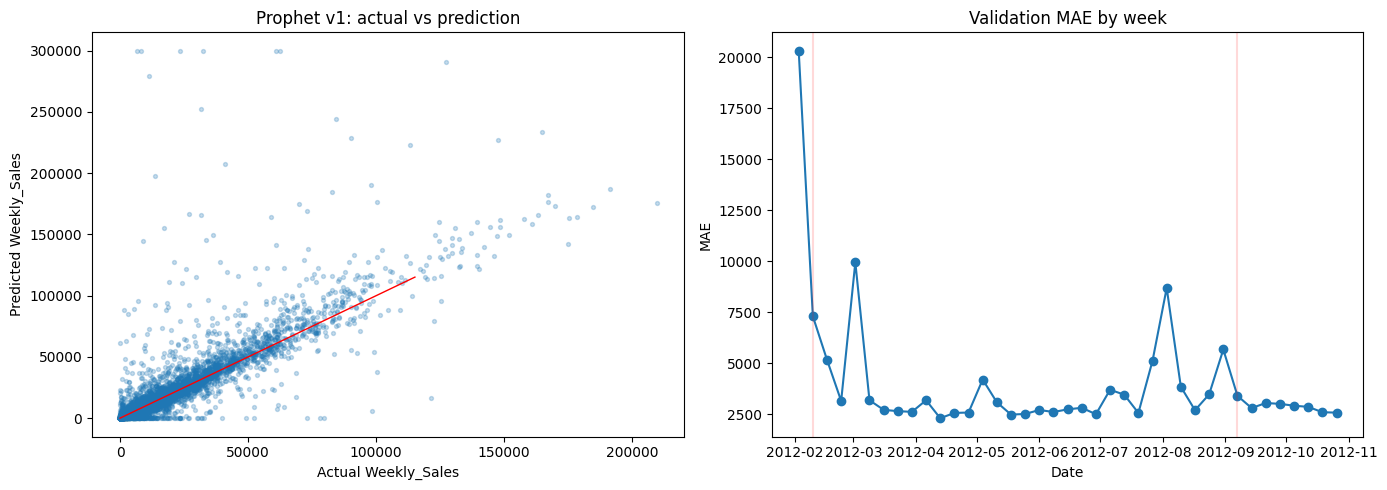

{'validation/wmae': 4236.684820311984,
 'validation/mae': 4005.8699315131007,
 'validation/seasonal_naive_wmae': 1604.2696976819943,
 'validation/improvement_vs_seasonal_naive_pct': -164.08806614209325,
 'fit/series_total': 3331,
 'fit/series_fit_ok': 3259,
 'fit/series_fallback': 72,
 'fit/elapsed_minutes': 9.598718825976054}

In [10]:
run = wandb.init(
    entity=CONFIG["wandb_entity"],
    project=CONFIG["wandb_project"],
    group=CONFIG["wandb_group"],
    name=CONFIG["run_name"],
    job_type="experiment_train",
    tags=["prophet", "classical-statistical", "experiment", "external-covariates", "all-series", "wmae"],
    config={**CONFIG, **split_summary},
    save_code=True,
)

val_pred_path = OUTPUT_DIR / "prophet_v1_validation_predictions.csv"
series_info_path = OUTPUT_DIR / "prophet_v1_series_info.csv"
metrics_path = OUTPUT_DIR / "prophet_v1_metrics.json"
config_path = OUTPUT_DIR / "prophet_v1_config.json"
feature_coverage_path = OUTPUT_DIR / "prophet_v1_feature_coverage.csv"

val_pred_df.to_csv(val_pred_path, index=False)
series_info_df.to_csv(series_info_path, index=False)
metrics_path.write_text(json.dumps(metrics, indent=2))
config_path.write_text(json.dumps({**CONFIG, **split_summary}, indent=2))
feature_coverage.reset_index().to_csv(feature_coverage_path, index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = val_pred_df.sample(min(8000, len(val_pred_df)), random_state=SEED)
axes[0].scatter(sample["Weekly_Sales"], sample["Prediction"], s=8, alpha=0.25)
max_axis = np.nanpercentile(sample[["Weekly_Sales", "Prediction"]].to_numpy(), 99)
axes[0].plot([0, max_axis], [0, max_axis], color="red", linewidth=1)
axes[0].set_title("Prophet v1: actual vs prediction")
axes[0].set_xlabel("Actual Weekly_Sales")
axes[0].set_ylabel("Predicted Weekly_Sales")

weekly_errors = (
    val_pred_df.groupby("Date", as_index=False)
    .agg(Weekly_MAE=("AbsError", "mean"), IsHoliday=("IsHoliday", "max"))
)
axes[1].plot(weekly_errors["Date"], weekly_errors["Weekly_MAE"], marker="o")
for date in weekly_errors.loc[weekly_errors["IsHoliday"], "Date"]:
    axes[1].axvline(date, color="red", alpha=0.15)
axes[1].set_title("Validation MAE by week")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("MAE")
plt.tight_layout()
plot_path = OUTPUT_DIR / "prophet_v1_validation_diagnostics.png"
fig.savefig(plot_path, dpi=160)
plt.show()

artifact = wandb.Artifact(
    CONFIG["artifact_name"],
    type="model-evaluation",
    description="Prophet v1 validation predictions, covariate coverage and diagnostics. Per-series models are not serialized during experimentation.",
    metadata={**CONFIG, **metrics, **split_summary},
)
for path in [val_pred_path, series_info_path, metrics_path, config_path, feature_coverage_path, plot_path]:
    artifact.add_file(str(path))
run.log_artifact(artifact, aliases=["v1", "validation", "latest"])

wandb.log({
    **metrics,
    "data/external_covariate_table": wandb.Table(dataframe=feature_coverage.reset_index()),
    "validation/prediction_table": wandb.Table(dataframe=val_pred_df.sample(min(20000, len(val_pred_df)), random_state=SEED)),
    "validation/series_info": wandb.Table(dataframe=series_info_df),
    "validation/weekly_errors": wandb.Table(dataframe=weekly_errors),
    "validation/diagnostic_plot": wandb.Image(str(plot_path)),
})
for key, value in metrics.items():
    run.summary[key] = value
run.summary["validation_predictions_path"] = str(val_pred_path)
run.summary["seasonal_naive_wmae"] = float(seasonal_naive_wmae)
run.summary["prophet_wmae"] = float(prophet_wmae)
run.summary["external_regressor_count"] = int(len(CONFIG["external_regressors"]))

metrics

## End run

The experiment deliberately does not generate a Kaggle submission. It must first be evaluated against the same all-series validation split as the baseline.

In [11]:
print("Experiment complete. W&B contains metrics, diagnostics, validation predictions and covariate coverage.")

Experiment complete. W&B contains metrics, diagnostics, validation predictions and covariate coverage.


In [12]:
wandb.finish()


fit/elapsed_minutes,▁
fit/series_fallback,▁
fit/series_fit_ok,▁
fit/series_total,▁
validation/improvement_vs_seasonal_naive_pct,▁
validation/mae,▁
validation/seasonal_naive_wmae,▁
validation/wmae,▁
external_regressor_count,9
fit/elapsed_minutes,9.59872
fit/series_fallback,72
